In [1]:
import numpy as np
import scipy.stats as stats
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

## Probability and uncertainty

So far, we've emphasized ways that the properties of a data distribution can help us form expectations about what events are likely. 
Let's formalize this intuition a bit using some ideas from _information theory_. 

Imagine that you are looking at the distribution of grades in a class over the last few terms. Here are two different scenarios for how the grade distributions could look: 


In [2]:
rng = np.random.default_rng(2)

scenario_1 = stats.gumbel_l(loc = 95, scale = 0.5).rvs(size=500, random_state=rng)
scenario_2 = stats.gumbel_l(loc = 95, scale = 3).rvs(size=500, random_state=rng)

Lets plot these two scenarios side by side:

Text(76, 45, 'Scenario 2')

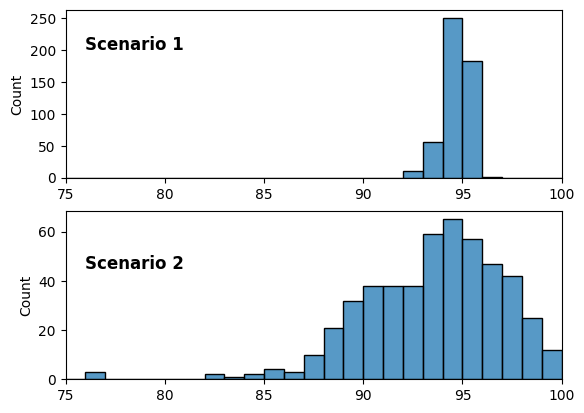

In [3]:
plt.subplot(2, 1, 1)
sns.histplot(scenario_1, bins=np.arange(75, 101, 1))
plt.xlim(75, 100)
plt.text(76, 200, "Scenario 1", fontsize=12, fontweight='bold')

plt.subplot(2, 1, 2)
sns.histplot(scenario_2, bins=np.arange(75, 101, 1))
plt.xlim(75, 100)
plt.text(76, 45, "Scenario 2", fontsize=12, fontweight='bold')


If you want to be sure you're going to get an A in class- let's say that means, a 90 or better- which scenario would give you more certainty that you'll end up with an A? 

- In **Scenario 1**, where our distribution of outcomes (historically) is relatively narrow, that means grades typically fall only within a small range. It looks like historically everyone has gotten an A. As long as you expect this pattern will continue to hold, you might be pretty confident you'll also get an A! 

- In **Scenario 2** the distribution of outcomes is wider. Not everyone has gotten an A, historically. So- without knowing more about what factors have historically been associated with grades- you wouldn't be certain you'll get an A. 

When we're reasoning about the certainty we'll get an A (or any other outcome) based on the shape of the distribution, we're often doing an intuitive calculation that can be formalized through the concept of _entropy_.

### Introducing entropy
The entropy of a random variable is the average level of surprise you have when you see its outcome.

If the grades are 99% A, then you have very little surprise when an A is realized, but a lot when something else is realized. We're going to quantify the amount of surprise using a mathematical formula.

#### The formula
Given a discrete random variable $x$, which takes values in the set $X$ distributed according to $p$ : $X$ → [ 0 , 1 ], 

$H(x)$ = -$\sum_{x \in X}^{} p(x) * \log p(x)$



This looks a little complicated- but it's not as terrible as it can seem at first. Imagine that we want to know the entropy $H(x)$ of the $x$, my letter grade in class. 

Since entropy is defined on categorical variables, let's make our example super simple by breaking down our distributions into 3 categories of grades: A, B, or C.

In [4]:
bins = [70, 80, 90, np.inf]
letter_grades = ["C","B","A"]

df1 = pd.DataFrame({'score': scenario_1})
df1['grade'] = pd.cut(df1['score'], bins, labels=letter_grades)

df1.value_counts('grade')

grade
A    500
C      0
B      0
Name: count, dtype: int64

In [5]:
def calculate_grade_entropy(df):
    letter_grades = df.value_counts('grade').index
    h = 0 
    for letter in letter_grades:
        # Calculate the proportion of students with a grade of letter
        proportion = (df['grade'] == letter).mean()
        if proportion == 0:
            continue
        else:
            log_likelihood = np.log2(proportion)
            h -= proportion * log_likelihood
    return h

# Print the entropy
print("Entropy of scenario 1: ", calculate_grade_entropy(df1))

Entropy of scenario 1:  0.0


Now let's try for scenario 2:

In [6]:
df2 = pd.DataFrame({'score': scenario_2})
df2['grade'] = pd.cut(df2['score'], bins, labels=letter_grades)
df2.value_counts('grade')

grade
A    422
B     75
C      3
Name: count, dtype: int64

In [7]:
print("Entropy of scenario 2: ", calculate_grade_entropy(df2))

Entropy of scenario 2:  0.6613439908145137


### Entropy and information
We can see that in Scenario 1, when _everyone_ in class has historically gotten an A, the entropy is 0. Note that it is expressed in _bits_ of information (when we use $\log_2$ for our calculation, as above). In other words, when everyone gets an A, the grade variable contains no information! 

When there is some variability in grades- some people get B's and C's- the entropy is higher. The grade conveys more information, on average.

### Maximizing entropy
As a final thought experiment, let's look at how entropy is maximized. What scenario would give us the most uncertainty about our eventual grade going into a class?

<Axes: ylabel='Count'>

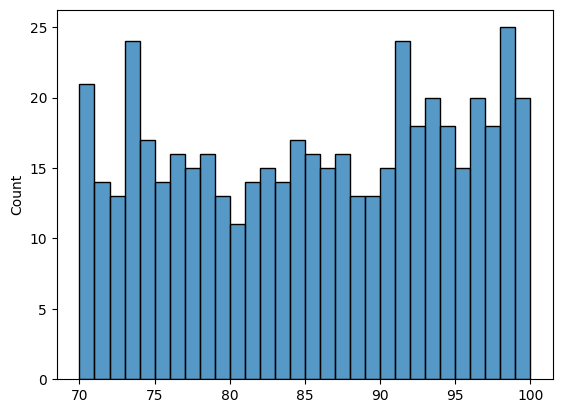

In [8]:
scenario_3 = stats.uniform(loc = 70, scale = 30).rvs(size=500, random_state=rng)

sns.histplot(scenario_3, bins=np.arange(70, 101, 1))

In [9]:
# Save this to a dataframe
df3 = pd.DataFrame({'score': scenario_3})
df3['grade'] = pd.cut(df3['score'], bins, labels=letter_grades)
df3.value_counts('grade')

grade
A    193
C    163
B    144
Name: count, dtype: int64

In [10]:
print("Entropy of scenario 3: ", calculate_grade_entropy(df3))

Entropy of scenario 3:  1.5744720895818909


Note that the theoretical maximum of entropy for when there are 3 equally likely outcomes is: 

In [11]:
np.log2(3)

1.584962500721156

We'll leave the derivation of why this is the theoretical maximum as an exercise for the reader- with some hints in the weekly reading!

### The entropy function
You will not always have to write your own entropy function- as long as you have a probability mass function to work from, you can use the `entropy()` function in the `scipy.stats` module. Here's an example, working _directly_ from a theoretical distribution

When you define a distribution as a data-generating process in `scipy.stats`, you can get the entropy of the probability mass function directly. Let's consider the binomial distribution for simulating coin flips:

In [12]:
distribution = stats.binom(n=1, p=0.5) 
distribution.rvs(size=100, random_state=rng)

array([0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1,
       0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1])

In [13]:
pmf = [distribution.pmf(x) for x in range(2)]
pmf

[0.4999999999999999, 0.5]

In [14]:
stats.entropy(pmf, base = 2)

0.9999999999999999

We can use these functions to replicate a classic exploration of entropy with a coin flip experiment. Imagine that we are varying how unfair a coin is- we start with a coin that only ever comes up tails. Then we slowly vary the weighting so it becomes more fair, until it is perfectly fair. And then we keep varying the weighting until it only ever comes up heads. How does the entropy change?

In [15]:
p_range = np.linspace(0, 1, 100)
entropies = []

for p in p_range:
    distribution = stats.binom(n=1, p=p) 
    pmf = [distribution.pmf(x) for x in range(2)]
    entropies.append(stats.entropy(pmf, base = 2))

In [12]:
p_range = np.linspace(0, 1, 100)
entropy = []

for p in p_range:
    distribution = stats.binom(n=1, p=p) 
    pmf = [distribution.pmf(x) for x in range(2)]
    entropy.append(stats.entropy(pmf, base = 2))

<Axes: xlabel='p', ylabel='entropy'>

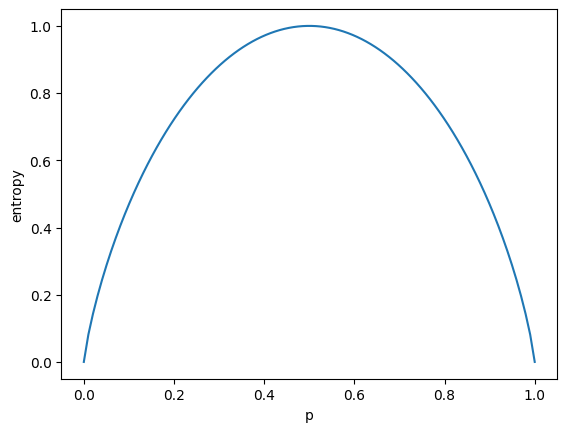

In [13]:
entropies_df = pd.DataFrame({'p': p_range, 'entropy': entropies})
sns.lineplot(data=entropies_df, x='p', y='entropy')